In [1]:
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.ticker as ticker
import torchvision


import importlib
import Optimizers.SVRG as SVRG_module
import Optimizers.NFG_SVRG as NFG_SVRG_module
import Optimizers.ASAI_SVRG as ASAI_SVRG_module

In [2]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [3]:
LEARNING_RATE = 0.001
BATCH_SIZE = 64
EPOCHS = 500
SEED = 42
KEEP = False

In [4]:
set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True, num_workers = 0)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle = False, num_workers = 0)

class CNN_Model(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = torch.nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = torch.nn.GroupNorm(8, 32)
        self.act1 = torch.nn.ReLU()
        self.pool1 = torch.nn.MaxPool2d(2)

        self.conv2 = torch.nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = torch.nn.GroupNorm(8, 64) 
        self.act2 = torch.nn.ReLU()
        self.pool2 = torch.nn.MaxPool2d(2)

        self.conv3 = torch.nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = torch.nn.GroupNorm(8, 128) 
        self.act3 = torch.nn.ReLU()
        self.pool3 = torch.nn.AdaptiveAvgPool2d((1, 1))

        self.fc1 = torch.nn.Linear(128, 100)
        self.act4 = torch.nn.ReLU()
        self.fc2 = torch.nn.Linear(100, 10)

    def forward(self, x):
        y = self.act1(self.bn1(self.conv1(x)))
        y = self.pool1(y)

        y = self.act2(self.bn2(self.conv2(y)))
        y = self.pool2(y)

        y = self.act3(self.bn3(self.conv3(y)))
        y = self.pool3(y)

        y = torch.flatten(y, 1)
        y = self.act4(self.fc1(y))
        y = self.fc2(y)
        return y     

In [5]:
ROOT_DIR = "outputs/CIFAR10_CNN_ver2"
TARGET_DIR = f"{ROOT_DIR}/{LEARNING_RATE}/{BATCH_SIZE}/{EPOCHS}/{SEED}"
os.makedirs(TARGET_DIR, exist_ok=True)

# SGD

In [6]:
set_seed(SEED)

SGD_DIR = f"{TARGET_DIR}/SGD"

if not os.path.exists(f"{SGD_DIR}/result.json"):
    model = CNN_Model().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr = LEARNING_RATE)

    SGD_train_loss_history = []
    SGD_test_loss_history = []
    SGD_train_acc_history = []
    SGD_test_acc_history = []
    SGD_x = []
    fg_count = 0

    for epoch in range(EPOCHS):
        print(f"epoch: {epoch + 1}")
        model.train()
        train_loss, correct, total = 0, 0, 0
        pb = tqdm(train_loader)
        for X, T in pb:
            X, T = X.to(device), T.to(device)

            optimizer.zero_grad()
            Y = model(X)
            loss = criterion(Y, T)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            pred = Y.argmax(dim=1)
            correct += (pred == T).sum().item()
            total += T.size(0)

            pb.set_postfix({"loss": loss.item(), "acc": correct / total})

        fg_count += 1
        train_loss /= len(train_loader)
        train_acc = correct / total

        SGD_x.append(fg_count)
        SGD_train_loss_history.append(train_loss)
        SGD_train_acc_history.append(train_acc)


        model.eval()
        test_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            pb = tqdm(test_loader)
            for X, T in pb:
                X, T = X.to(device), T.to(device)

                Y = model(X)
                loss = criterion(Y, T)

                test_loss += loss.item()

                pred = Y.argmax(dim=1)
                correct += (pred == T).sum().item()
                total += T.size(0)

                pb.set_postfix({"loss": loss.item(), "acc": correct / total})

        test_loss /= len(test_loader)
        test_acc = correct / total

        SGD_test_loss_history.append(test_loss)
        SGD_test_acc_history.append(test_acc)

        print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}", "|", f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

        if fg_count >= EPOCHS:
            break

    if KEEP:
        os.makedirs(SGD_DIR, exist_ok=True)
        with open(f"{SGD_DIR}/result.json", "w") as f:
            json.dump({
                "train_loss": SGD_train_loss_history,
                "train_acc": SGD_train_acc_history,
                "test_loss": SGD_test_loss_history,
                "test_acc": SGD_test_acc_history,
                "x": SGD_x
            }, f, indent = 4)

epoch: 1


100%|██████████| 157/157 [00:01<00:00, 154.57it/s, loss=2.25, acc=0.207]


Train Loss: 2.2909, Acc: 0.1487 | Test Loss: 2.2686, Acc: 0.2069
epoch: 2


100%|██████████| 157/157 [00:00<00:00, 171.93it/s, loss=2.13, acc=0.21] 


Train Loss: 2.2345, Acc: 0.2065 | Test Loss: 2.1885, Acc: 0.2101
epoch: 3


...

Train Loss: 0.3547, Acc: 0.8768 | Test Loss: 0.9062, Acc: 0.7124
epoch: 499


100%|██████████| 157/157 [00:00<00:00, 178.97it/s, loss=0.747, acc=0.673]


Train Loss: 0.3541, Acc: 0.8777 | Test Loss: 1.0645, Acc: 0.6731
epoch: 500


100%|██████████| 157/157 [00:00<00:00, 177.01it/s, loss=0.63, acc=0.728] 

Train Loss: 0.3553, Acc: 0.8784 | Test Loss: 0.8766, Acc: 0.7282


# SVRG

In [7]:
set_seed(SEED)

import importlib
SVRG_module = importlib.import_module("Optimizers.SVRG")
SVRG_module = importlib.reload(SVRG_module)
SVRG = SVRG_module.SVRG

SVRG_DIR = f"{TARGET_DIR}/SVRG"

if not os.path.exists(f"{SVRG_DIR}/result.json"):
    model = CNN_Model().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = SVRG(model.parameters(), lr = LEARNING_RATE)

    SVRG_train_loss_history = []
    SVRG_test_loss_history = []
    SVRG_train_acc_history = []
    SVRG_test_acc_history = []
    SVRG_x = []
    fg_count = 0

    for epoch in range(EPOCHS):
        print(f"epoch: {epoch + 1}")
        model.train()
        train_loss, correct, total = 0, 0, 0

        optimizer.calc_full_grads(model, train_loader, criterion)
        fg_count += 1

        pb = tqdm(train_loader)
        for X, T in pb:
            X, T = X.to(device), T.to(device)

            optimizer.calc_snapshot_grads(model, X, T, criterion)

            optimizer.zero_grad()
            Y = model(X)
            loss = criterion(Y, T)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            pred = Y.argmax(dim=1)
            correct += (pred == T).sum().item()
            total += T.size(0)

            pb.set_postfix({"loss": loss.item(), "acc": correct / total})

        fg_count += 2
        train_loss /= len(train_loader)
        train_acc = correct / total

        SVRG_x.append(fg_count)
        SVRG_train_loss_history.append(train_loss)
        SVRG_train_acc_history.append(train_acc)


        model.eval()
        test_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            pb = tqdm(test_loader)
            for X, T in pb:
                X, T = X.to(device), T.to(device)

                Y = model(X)
                loss = criterion(Y, T)

                test_loss += loss.item()

                pred = Y.argmax(dim=1)
                correct += (pred == T).sum().item()
                total += T.size(0)

                pb.set_postfix({"loss": loss.item(), "acc": correct / total})

        test_loss /= len(test_loader)
        test_acc = correct / total

        SVRG_test_loss_history.append(test_loss)
        SVRG_test_acc_history.append(test_acc)

        print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}", "|", f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

        if fg_count >= EPOCHS:
            break


    if KEEP:
        os.makedirs(SVRG_DIR, exist_ok=True)
        with open(f"{SVRG_DIR}/result.json", "w") as f:
            json.dump({
                "train_loss": SVRG_train_loss_history,
                "train_acc": SVRG_train_acc_history,
                "test_loss": SVRG_test_loss_history,
                "test_acc": SVRG_test_acc_history,
                "x": SVRG_x
            }, f, indent = 4)

epoch: 1


100%|██████████| 157/157 [00:00<00:00, 198.86it/s, loss=2.25, acc=0.209]


Train Loss: 2.2912, Acc: 0.1505 | Test Loss: 2.2697, Acc: 0.2095
epoch: 2


100%|██████████| 157/157 [00:00<00:00, 187.70it/s, loss=2.13, acc=0.208]


Train Loss: 2.2359, Acc: 0.2081 | Test Loss: 2.1905, Acc: 0.2076
epoch: 3


...

Train Loss: 0.6715, Acc: 0.7632 | Test Loss: 0.9544, Acc: 0.6621
epoch: 166


100%|██████████| 157/157 [00:00<00:00, 180.85it/s, loss=0.841, acc=0.675]


Train Loss: 0.7018, Acc: 0.7536 | Test Loss: 0.9356, Acc: 0.6749
epoch: 167


100%|██████████| 157/157 [00:00<00:00, 178.75it/s, loss=0.697, acc=0.663]

Train Loss: 0.6950, Acc: 0.7540 | Test Loss: 0.9267, Acc: 0.6630


# No Full Grad SVRG

In [19]:
set_seed(SEED)

EPOCHS = 100

import importlib
NFG_SVRG_module = importlib.import_module("Optimizers.NFG_SVRG")
NFG_SVRG_module = importlib.reload(NFG_SVRG_module)
NFG_SVRG = NFG_SVRG_module.NFG_SVRG

NFG_SVRG_DIR = f"{TARGET_DIR}/NFG_SVRG"

if not os.path.exists(f"{NFG_SVRG_DIR}/result.json"):
    model = CNN_Model().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = NFG_SVRG(model.parameters(), lr = LEARNING_RATE)

    NFG_SVRG_train_loss_history = []
    NFG_SVRG_test_loss_history = []
    NFG_SVRG_train_acc_history = []
    NFG_SVRG_test_acc_history = []
    NFG_SVRG_norm_history = []
    NFG_SVRG_x = []
    fg_count = 0

    for epoch in range(EPOCHS):
        print(f"epoch: {epoch + 1}")
        model.train()
        train_loss, correct, total = 0, 0, 0

        optimizer.init_epoch()

        pb = tqdm(train_loader)
        for X, T in pb:
            X, T = X.to(device), T.to(device)

            optimizer.calc_snapshot_grads(model, X, T, criterion)

            optimizer.zero_grad()
            Y = model(X)
            loss = criterion(Y, T)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            pred = Y.argmax(dim=1)
            correct += (pred == T).sum().item()
            total += T.size(0)

            pb.set_postfix({"loss": loss.item(), "acc": correct / total})

        # diff_norm = optimizer.calc_diff_norm(model, train_loader, criterion)
        # NFG_SVRG_norm_history.append(diff_norm)

        optimizer.end_epoch()

        fg_count += 2
        train_loss /= len(train_loader)
        train_acc = correct / total

        NFG_SVRG_x.append(fg_count)
        NFG_SVRG_train_loss_history.append(train_loss)
        NFG_SVRG_train_acc_history.append(train_acc)


        model.eval()
        test_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            pb = tqdm(test_loader)
            for X, T in pb:
                X, T = X.to(device), T.to(device)

                Y = model(X)
                loss = criterion(Y, T)

                test_loss += loss.item()

                pred = Y.argmax(dim=1)
                correct += (pred == T).sum().item()
                total += T.size(0)

                pb.set_postfix({"loss": loss.item(), "acc": correct / total})

        test_loss /= len(test_loader)
        test_acc = correct / total

        NFG_SVRG_test_loss_history.append(test_loss)
        NFG_SVRG_test_acc_history.append(test_acc)

        print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f} | norm: {diff_norm:.4f}")

        if fg_count >= EPOCHS:
            break


    if KEEP:
        os.makedirs(NFG_SVRG_DIR, exist_ok=True)
        with open(f"{NFG_SVRG_DIR}/result.json", "w") as f:
            json.dump({
                "train_loss": NFG_SVRG_train_loss_history,
                "train_acc": NFG_SVRG_train_acc_history,
                "test_loss": NFG_SVRG_test_loss_history,
                "test_acc": NFG_SVRG_test_acc_history,
                "x": NFG_SVRG_x,
                'norm': NFG_SVRG_norm_history
            }, f, indent = 4)

epoch: 1


  0%|          | 0/782 [00:00<?, ?it/s]

100%|██████████| 157/157 [00:00<00:00, 161.10it/s, loss=2.25, acc=0.0986]


Train Loss: 2.3202, Acc: 0.0986 | Test Loss: 2.3199, Acc: 0.0986 | norm: 0.3360
epoch: 2


100%|██████████| 157/157 [00:00<00:00, 159.52it/s, loss=2.26, acc=0.212]


...

Train Loss: 1.8482, Acc: 0.3131 | Test Loss: 2.0586, Acc: 0.2468 | norm: 0.3360
epoch: 36


100%|██████████| 157/157 [00:00<00:00, 157.95it/s, loss=1.95, acc=0.229]


Train Loss: 2.0750, Acc: 0.2161 | Test Loss: 2.0266, Acc: 0.2285 | norm: 0.3360
epoch: 37


 68%|██████▊   | 106/157 [00:00<00:00, 155.77it/s, loss=1.79, acc=0.275]


KeyboardInterrupt: 

# ASAI-SVRG

In [ ]:
set_seed(SEED)

import importlib
ASAI_SVRG_module = importlib.import_module("Optimizers.ASAI_SVRG")
ASAI_SVRG_module = importlib.reload(ASAI_SVRG_module)
ASAI_SVRG = ASAI_SVRG_module.ASAI_SVRG

ASAI_SVRG_DIR = f"{TARGET_DIR}/ASAI_SVRG"

if not os.path.exists(f"{ASAI_SVRG_DIR}/result.json"):
    model = CNN_Model().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = ASAI_SVRG(model.parameters(), lr = LEARNING_RATE)

    ASAI_SVRG_train_loss_history = []
    ASAI_SVRG_test_loss_history = []
    ASAI_SVRG_train_acc_history = []
    ASAI_SVRG_test_acc_history = []
    ASAI_SVRG_norm_history = []
    ASAI_SVRG_x = []
    fg_count = 0

    for epoch in range(EPOCHS):
        print(f"epoch: {epoch + 1}")
        model.train()
        train_loss, correct, total = 0, 0, 0

        optimizer.init_epoch()

        pb = tqdm(train_loader)
        for X, T in pb:
            X, T = X.to(device), T.to(device)

            optimizer.calc_snapshot_grads(model, X, T, criterion)

            optimizer.zero_grad()
            Y = model(X)
            loss = criterion(Y, T)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            pred = Y.argmax(dim=1)
            correct += (pred == T).sum().item()
            total += T.size(0)

            pb.set_postfix({"loss": loss.item(), "acc": correct / total})

        diff_norm = optimizer.calc_diff_norm(model, train_loader, criterion)
        ASAI_SVRG_norm_history.append(diff_norm)

        optimizer.end_epoch()

        fg_count += 2
        train_loss /= len(train_loader)
        train_acc = correct / total

        ASAI_SVRG_x.append(fg_count)
        ASAI_SVRG_train_loss_history.append(train_loss)
        ASAI_SVRG_train_acc_history.append(train_acc)


        model.eval()
        test_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            pb = tqdm(test_loader)
            for X, T in pb:
                X, T = X.to(device), T.to(device)

                Y = model(X)
                loss = criterion(Y, T)

                test_loss += loss.item()

                pred = Y.argmax(dim=1)
                correct += (pred == T).sum().item()
                total += T.size(0)

                pb.set_postfix({"loss": loss.item(), "acc": correct / total})

        test_loss /= len(test_loader)
        test_acc = correct / total

        ASAI_SVRG_test_loss_history.append(test_loss)
        ASAI_SVRG_test_acc_history.append(test_acc)

        print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f} | norm: {diff_norm:.4f}")

        if fg_count >= EPOCHS:
            break


    if KEEP:
        with open(f"{ASAI_SVRG_DIR}/result.json", "w") as f:
            json.dump({
                "train_loss": ASAI_SVRG_train_loss_history,
                "train_acc": ASAI_SVRG_train_acc_history,
                "test_loss": ASAI_SVRG_test_loss_history,
                "test_acc": ASAI_SVRG_test_acc_history,
                "x": ASAI_SVRG_x,
                'norm': ASAI_SVRG_norm_history
            }, f, indent = 4)

epoch: 1


100%|██████████| 157/157 [00:00<00:00, 172.78it/s, loss=2.25, acc=0.0986]


Train Loss: 2.3202, Acc: 0.0986 | Test Loss: 2.3199, Acc: 0.0986 | norm: 0.0015
epoch: 2


100%|██████████| 157/157 [00:00<00:00, 166.62it/s, loss=2.27, acc=0.137]


Train Loss: 2.2905, Acc: 0.1487 | Test Loss: 2.2904, Acc: 0.1366 | norm: 0.3361
epoch: 3


...

Train Loss: 0.7426, Acc: 0.7386 | Test Loss: 0.8242, Acc: 0.7049 | norm: 0.2164
epoch: 249


100%|██████████| 157/157 [00:00<00:00, 165.65it/s, loss=0.859, acc=0.708]


Train Loss: 0.7541, Acc: 0.7331 | Test Loss: 0.8200, Acc: 0.7081 | norm: 1.9979
epoch: 250


100%|██████████| 157/157 [00:00<00:00, 166.42it/s, loss=0.855, acc=0.708]

Train Loss: 0.7331, Acc: 0.7405 | Test Loss: 0.8183, Acc: 0.7079 | norm: 1.2510


# 結果

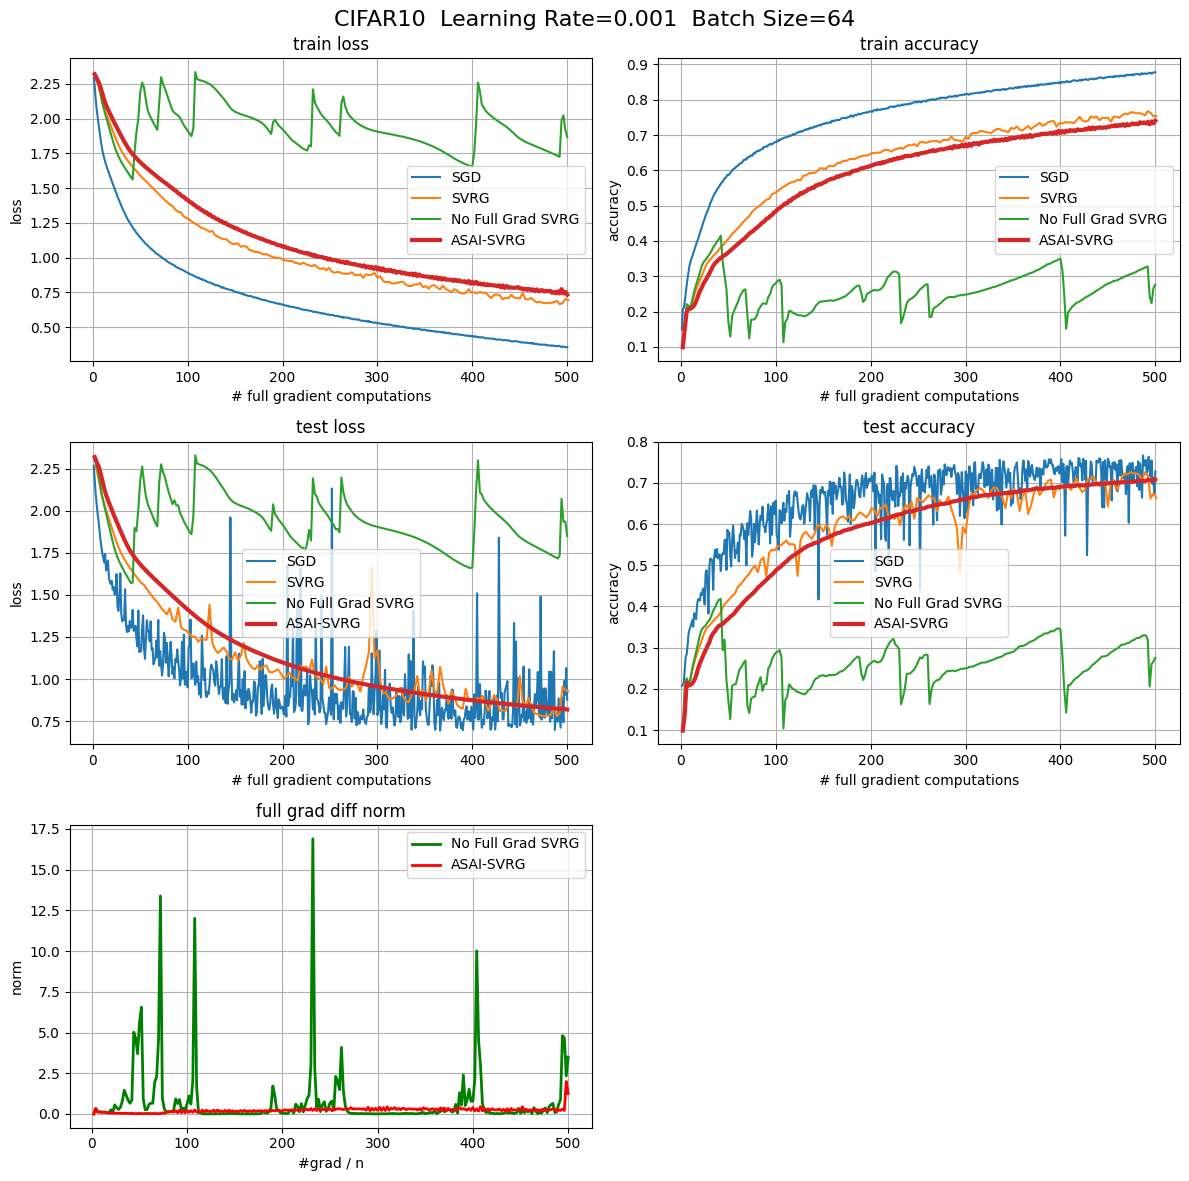

In [16]:
fig = plt.figure(figsize = (12, 12))
fig.suptitle(f"CIFAR10  Learning Rate={LEARNING_RATE}  Batch Size={BATCH_SIZE}" ,fontsize=16)
ax = fig.add_subplot(3, 2, 1)
ax.plot(SGD_x, SGD_train_loss_history, label = "SGD")
ax.plot(SVRG_x, SVRG_train_loss_history, label = "SVRG")
ax.plot(NFG_SVRG_x, NFG_SVRG_train_loss_history, label = "No Full Grad SVRG")
ax.plot(ASAI_SVRG_x, ASAI_SVRG_train_loss_history, label = "ASAI-SVRG", linewidth = 3)
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("loss")
ax.set_title("train loss")
ax.grid()
ax.legend()

ax = fig.add_subplot(3, 2, 2)
ax.plot(SGD_x, SGD_train_acc_history, label = "SGD")
ax.plot(SVRG_x, SVRG_train_acc_history, label = "SVRG")
ax.plot(NFG_SVRG_x, NFG_SVRG_train_acc_history, label = "No Full Grad SVRG")
ax.plot(ASAI_SVRG_x, ASAI_SVRG_train_acc_history, label = "ASAI-SVRG", linewidth = 3)
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("accuracy")
ax.set_title("train accuracy")
ax.grid()
ax.legend()

ax = fig.add_subplot(3, 2, 3)
ax.plot(SGD_x, SGD_test_loss_history, label = "SGD")
ax.plot(SVRG_x, SVRG_test_loss_history, label = "SVRG")
ax.plot(NFG_SVRG_x, NFG_SVRG_test_loss_history, label = "No Full Grad SVRG")
ax.plot(ASAI_SVRG_x, ASAI_SVRG_test_loss_history, label = "ASAI-SVRG", linewidth = 3)
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("loss")
ax.set_title("test loss")
ax.grid()
ax.legend()

ax = fig.add_subplot(3, 2, 4)
ax.plot(SGD_x, SGD_test_acc_history, label = "SGD")
ax.plot(SVRG_x, SVRG_test_acc_history, label = "SVRG")
ax.plot(NFG_SVRG_x, NFG_SVRG_test_acc_history, label = "No Full Grad SVRG")
ax.plot(ASAI_SVRG_x, ASAI_SVRG_test_acc_history, label = "ASAI-SVRG", linewidth = 3)
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("accuracy")
ax.set_title("test accuracy")
ax.grid()
ax.legend()

ax = fig.add_subplot(3, 2, 5)
ax.plot(NFG_SVRG_x , NFG_SVRG_norm_history, label = "No Full Grad SVRG", c='green', linewidth = 2)
ax.plot(ASAI_SVRG_x, ASAI_SVRG_norm_history, label = "ASAI-SVRG", c='red', linewidth = 2)
ax.set_xlabel("#grad / n")
ax.set_ylabel("norm")
ax.set_title("full grad diff norm")
ax.grid()
ax.legend()

plt.tight_layout()
plt.show()